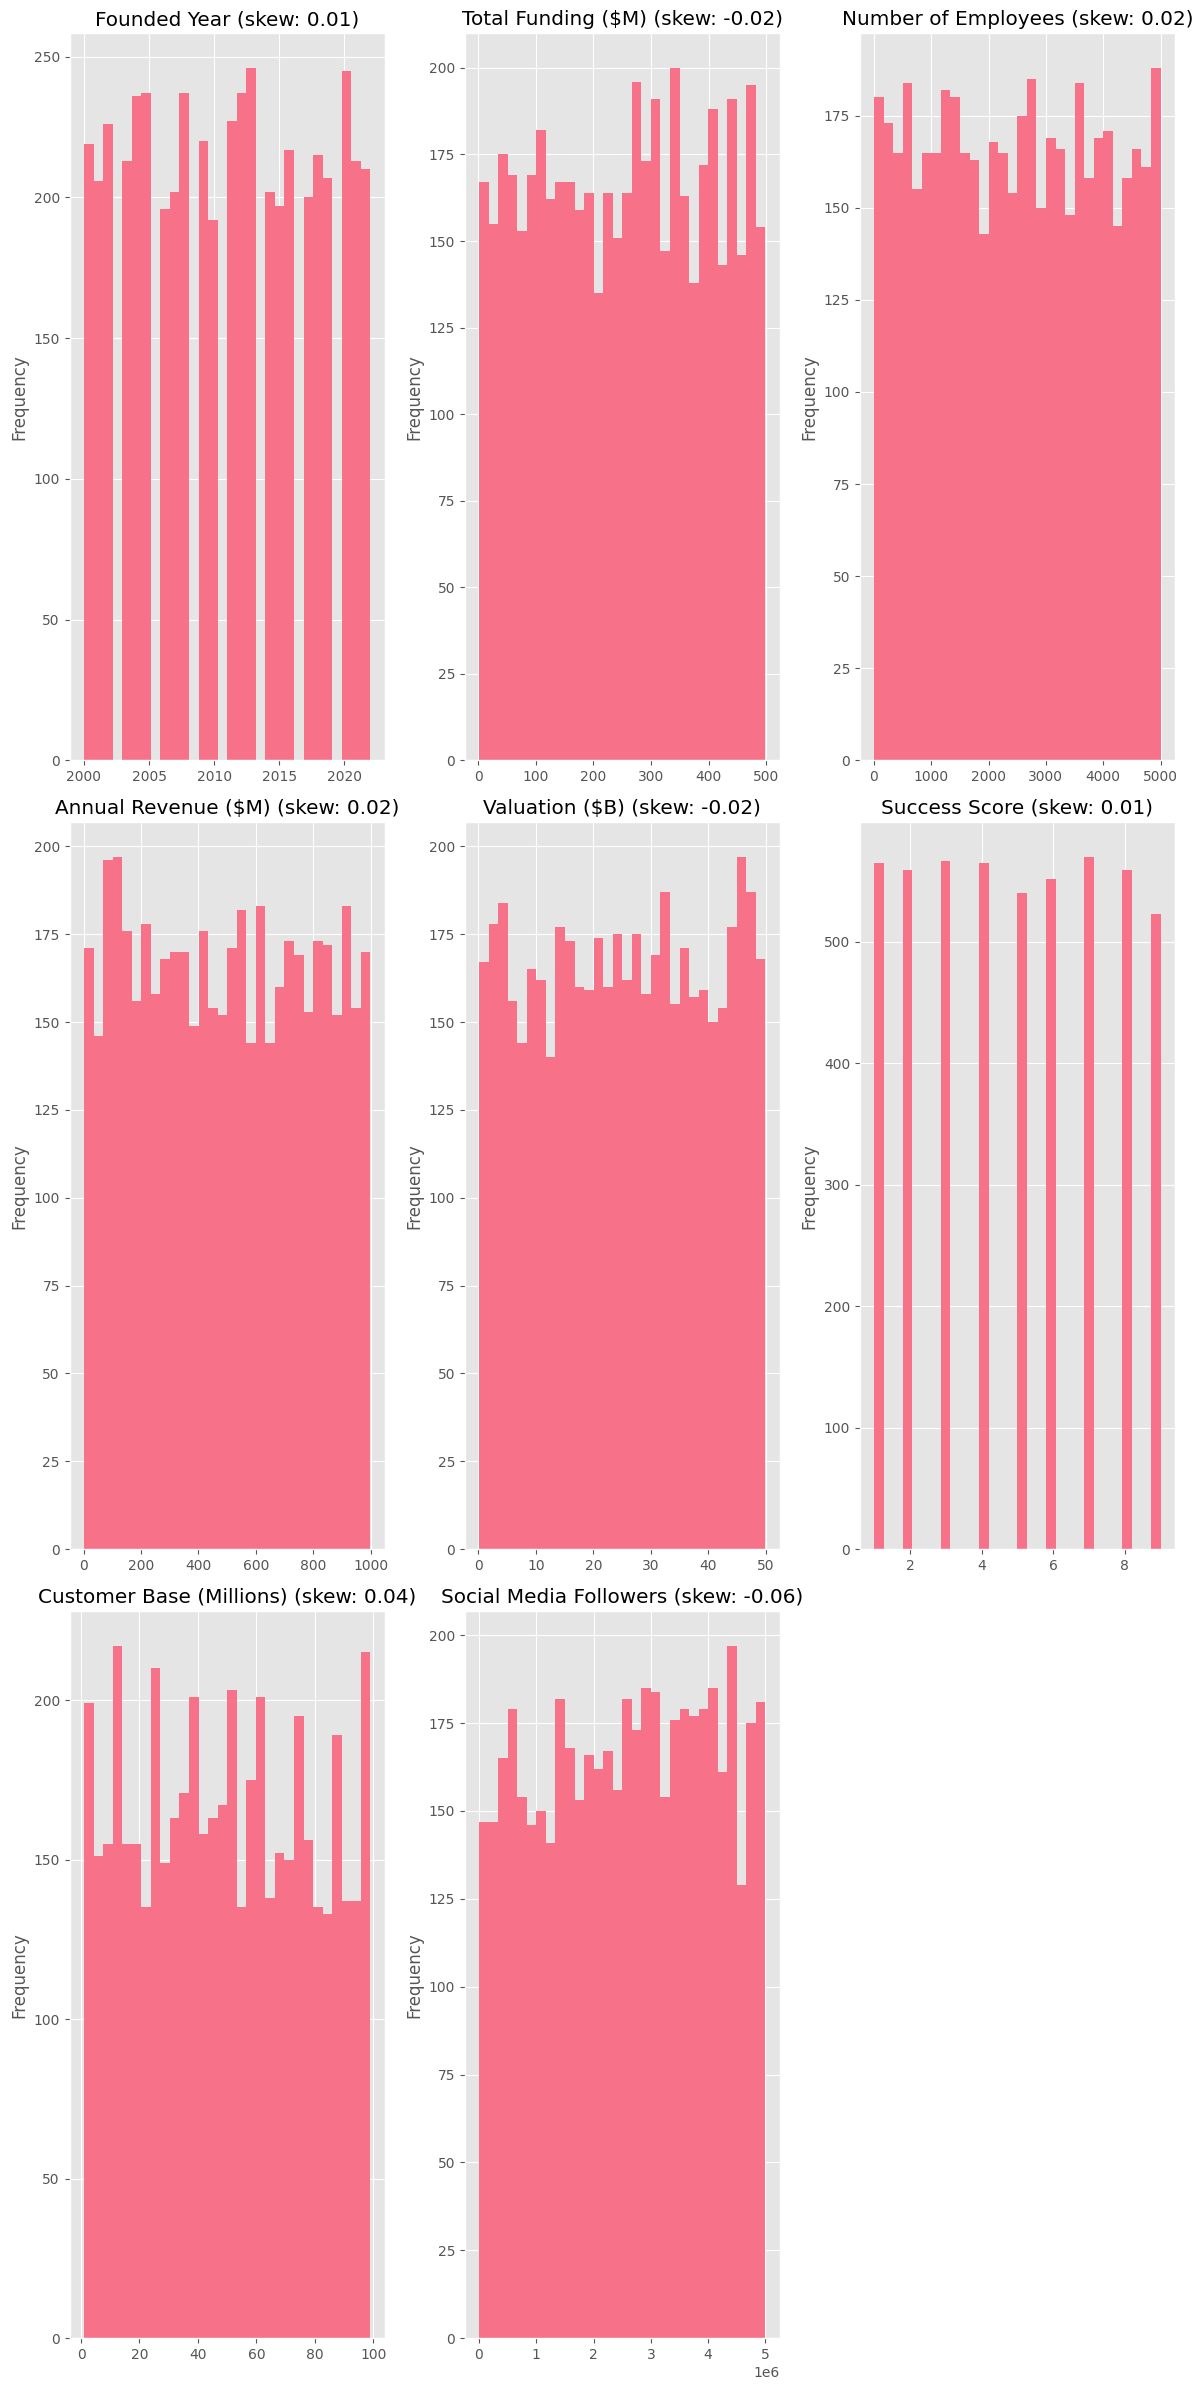

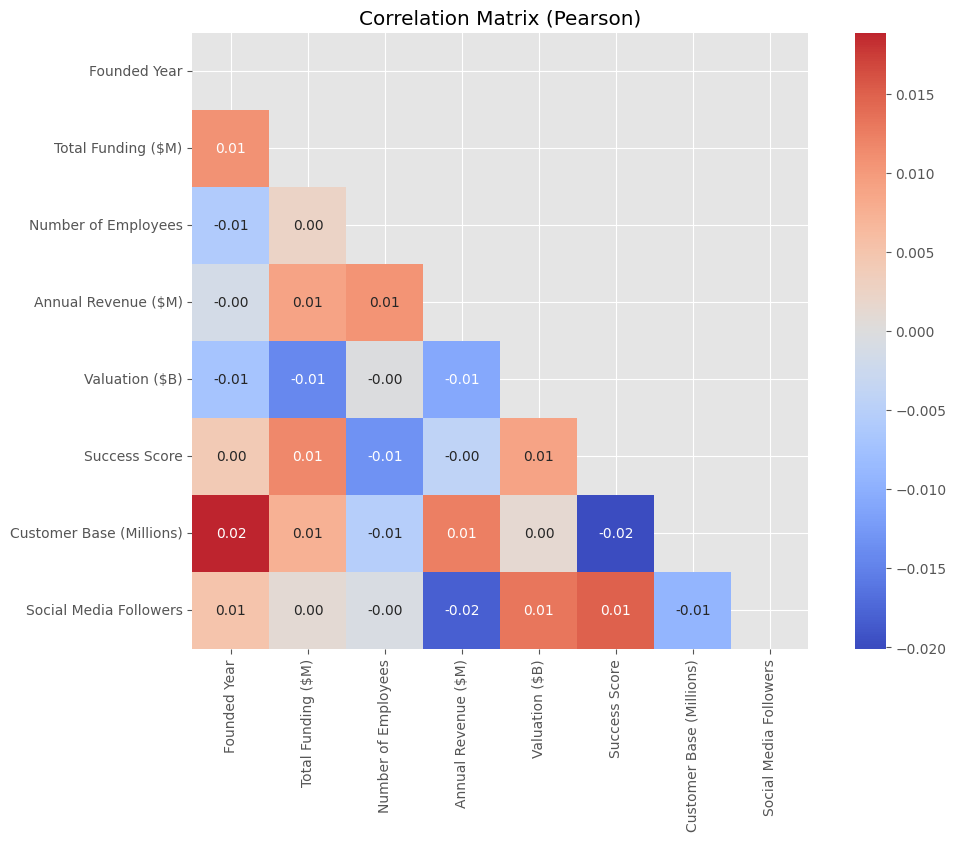

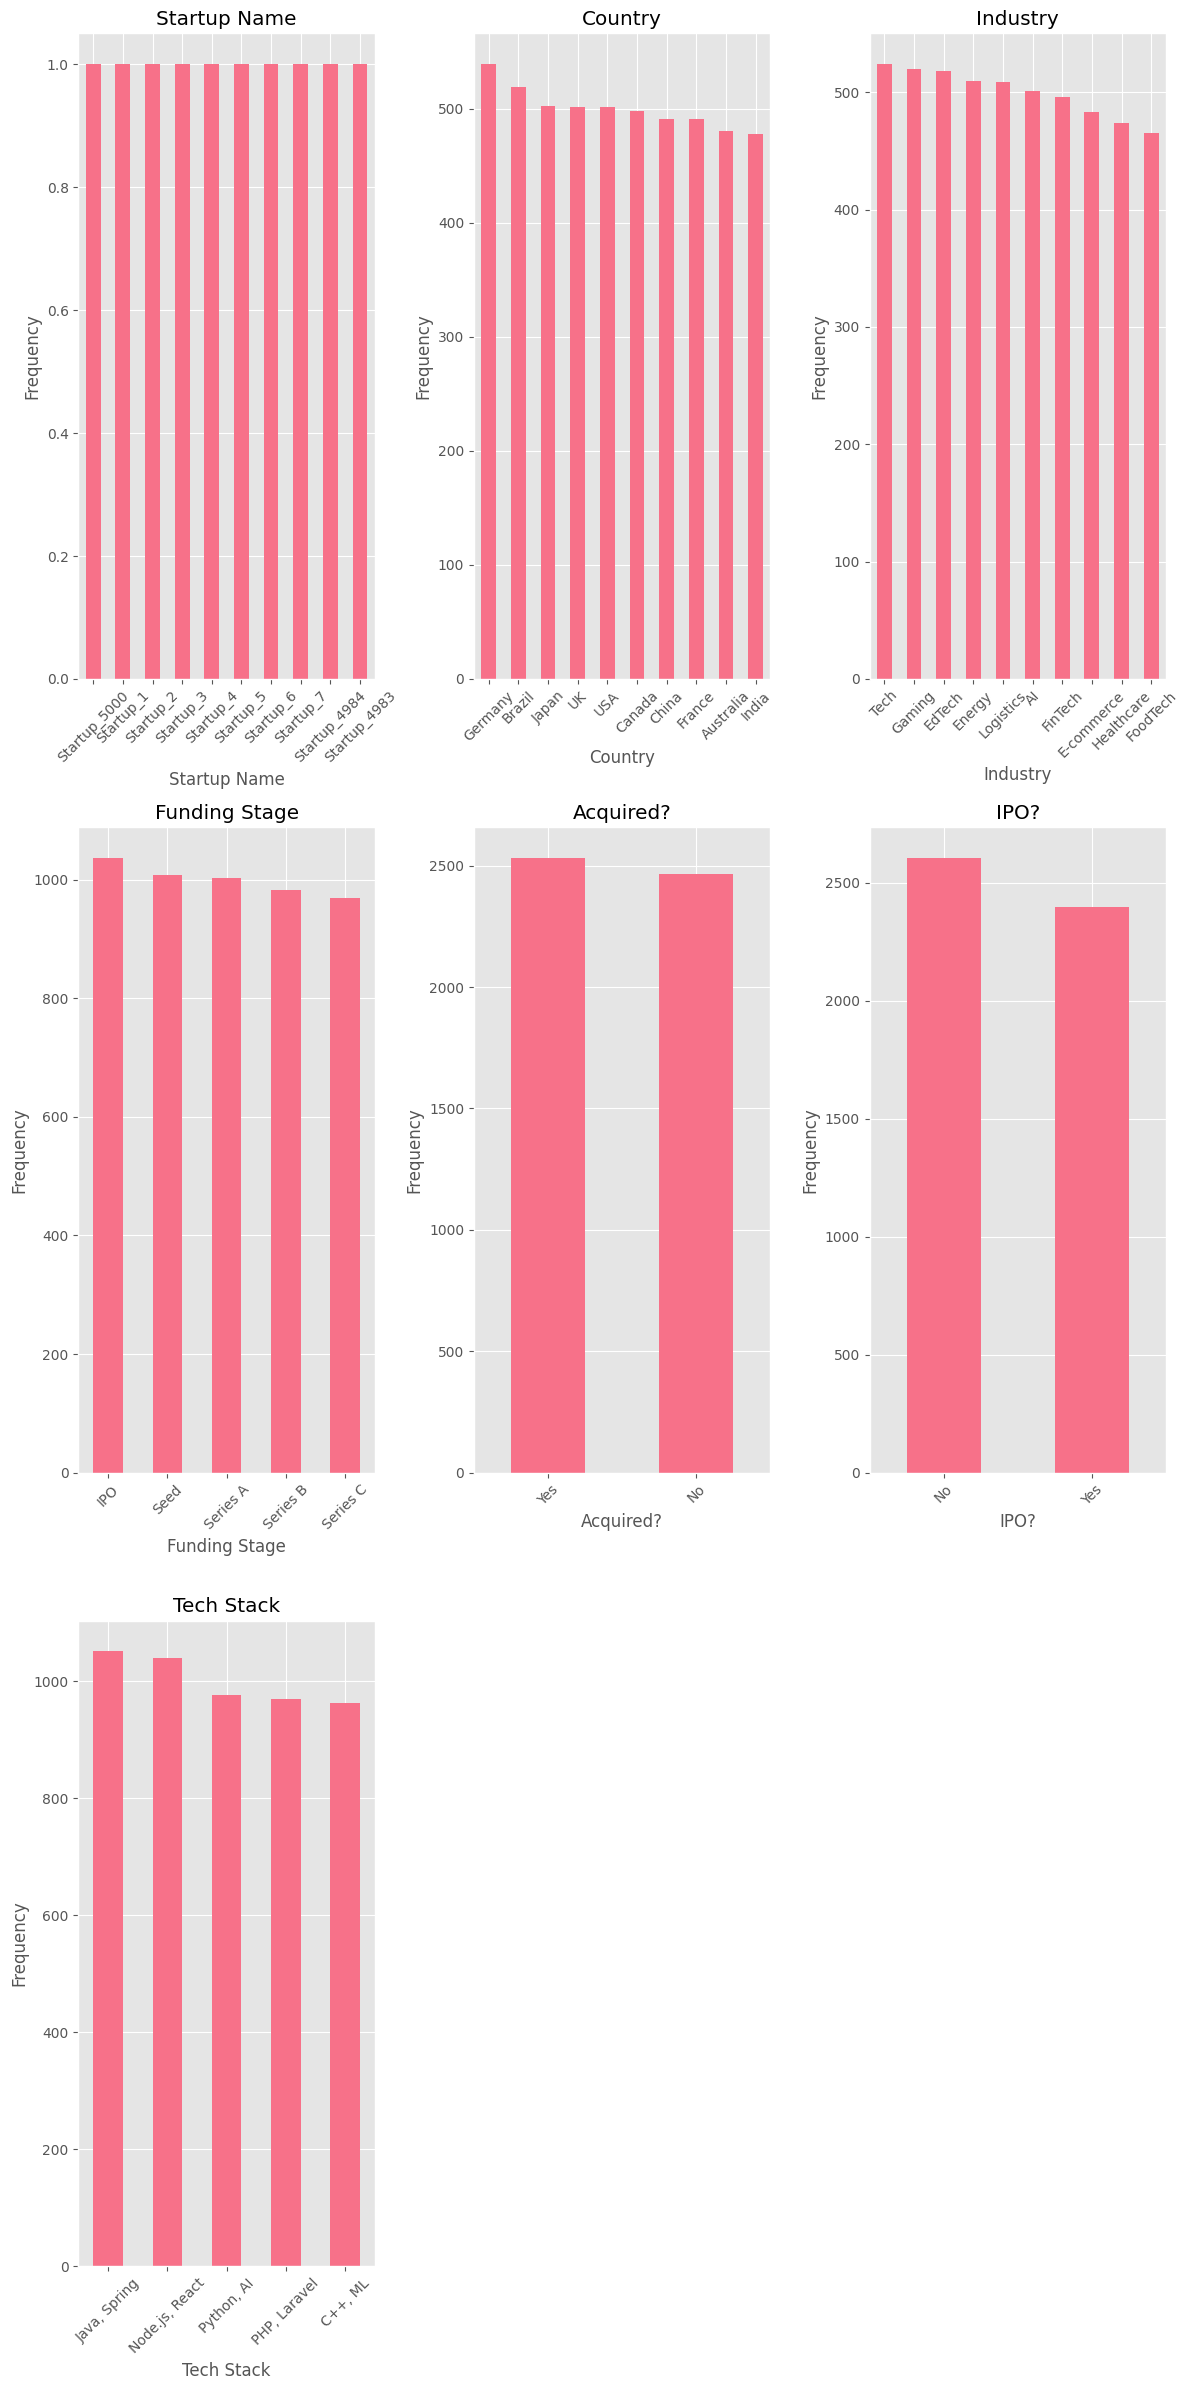

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8208
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 69
[LightGBM] [Info] Start training from score 4.941250


In [ ]:
# -*- coding: utf-8 -*-
"""
Global Startup Success Analysis - Enhanced ML Pipeline

A comprehensive machine learning pipeline for analyzing startup success factors
with improved modularity, scalability, and maintainability.

@author: Rafael Passos Domingues
"""

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             explained_variance_score, confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_regression, RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
import json
import logging
from datetime import datetime
from abc import ABC, abstractmethod
import inspect
from typing import Dict, List, Tuple, Union, Any, Optional
from dataclasses import dataclass
from enum import Enum
import kagglehub
from pathlib import Path
import os

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# ENUMS AND DATA CLASSES
# =============================================================================
class ProblemType(Enum):
    """Enumeration of problem types."""
    REGRESSION = 'regression'
    BINARY_CLASSIFICATION = 'binary_classification'
    MULTICLASS_CLASSIFICATION = 'multiclass_classification'

class ModelType(Enum):
    """Enumeration of model types."""
    RANDOM_FOREST = 'random_forest'
    GRADIENT_BOOSTING = 'gradient_boosting'
    LINEAR_REGRESSION = 'linear_regression'
    XGBOOST = 'xgboost'
    LIGHTGBM = 'lightgbm'
    SVM = 'svm'
    ENSEMBLE = 'ensemble'

@dataclass
class ModelConfig:
    """Configuration class for model parameters."""
    model_type: ModelType
    params: Dict[str, Any]
    tuning_grid: Optional[Dict[str, List[Any]]] = None

@dataclass
class DataConfig:
    """Configuration class for data parameters."""
    target_column: str
    problem_type: ProblemType
    test_size: float = 0.2
    random_state: int = 42
    categorical_features: Optional[List[str]] = None
    numerical_features: Optional[List[str]] = None
    exclude_features: Optional[List[str]] = None

# =============================================================================
# ABSTRACT BASE CLASSES
# =============================================================================
class BaseDataLoader(ABC):
    """Abstract base class for data loaders."""

    @abstractmethod
    def load_data(self, *args, **kwargs) -> pd.DataFrame:
        """Load data from source."""
        pass

    @abstractmethod
    def get_features_target(self, data: pd.DataFrame, target_column: str) -> Tuple[pd.DataFrame, pd.Series]:
        """Separate features and target."""
        pass

class BasePreprocessor(ABC):
    """Abstract base class for data preprocessors."""

    @abstractmethod
    def fit_transform(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> Any:
        """Fit and transform the data."""
        pass

    @abstractmethod
    def transform(self, X: pd.DataFrame) -> Any:
        """Transform new data using fitted preprocessor."""
        pass

class BaseModelTrainer(ABC):
    """Abstract base class for model trainers."""

    @abstractmethod
    def train(self, X: Any, y: pd.Series, model_type: ModelType) -> Any:
        """Train a model."""
        pass

    @abstractmethod
    def evaluate(self, X: Any, y: pd.Series, metrics: List[str]) -> Dict[str, float]:
        """Evaluate model performance."""
        pass

    @abstractmethod
    def tune_hyperparameters(self, X: Any, y: pd.Series, param_grid: Dict[str, List[Any]]) -> Any:
        """Tune model hyperparameters."""
        pass

# =============================================================================
# CONCRETE IMPLEMENTATIONS
# =============================================================================
class KaggleDataLoader(BaseDataLoader):
    """Concrete implementation for loading data from Kaggle."""

    def __init__(self):
        self.data = None
        self.metadata = {
            'source': None,
            'size': None,
            'loaded_at': None,
            'columns': None
        }

    def load_data(self, dataset_path: str, **kwargs) -> pd.DataFrame:
        """
        Load dataset from Kaggle using kagglehub.

        Args:
            dataset_path: Path to the Kaggle dataset
            **kwargs: Additional arguments for data loading

        Returns:
            Loaded DataFrame
        """
        try:
            logger.info(f"Loading dataset from Kaggle: {dataset_path}")

            # Download the dataset
            path = kagglehub.dataset_download(dataset_path)
            logger.info(f"Dataset downloaded to: {path}")

            # Convert to Path object if it's a string
            if isinstance(path, str):
                path = Path(path)

            # Look for CSV files in the downloaded directory
            csv_files = list(path.glob("*.csv"))

            if not csv_files:
                raise FileNotFoundError("No CSV files found in the dataset directory")

            # Load the first CSV file (assuming it's the main data file)
            data_file = csv_files[0]
            self.data = pd.read_csv(data_file, **kwargs)

            # Update metadata
            self.metadata.update({
                'source': dataset_path,
                'size': self.data.shape,
                'loaded_at': datetime.now().isoformat(),
                'columns': self.data.columns.tolist()
            })

            logger.info(f"Successfully loaded dataset with shape: {self.data.shape}")
            return self.data

        except Exception as e:
            logger.error(f"Error loading dataset: {str(e)}")
            raise

    def get_features_target(self, data: pd.DataFrame, target_column: str) -> Tuple[pd.DataFrame, pd.Series]:
        """
        Separate features and target variable.

        Args:
            data: Input DataFrame
            target_column: Name of the target column

        Returns:
            Tuple of (features, target)
        """
        if target_column not in data.columns:
            raise ValueError(f"Target column '{target_column}' not found in dataset")

        X = data.drop(columns=[target_column])
        y = data[target_column]

        return X, y

class StartupDataPreprocessor(BasePreprocessor):
    """Custom preprocessor for startup success data."""

    def __init__(self, config: DataConfig):
        self.config = config
        self.preprocessor = None
        self.feature_names = None
        self._validate_config()

    def _validate_config(self) -> None:
        """Validate the configuration."""
        if not isinstance(self.config, DataConfig):
            raise TypeError("config must be an instance of DataConfig")

    def _detect_feature_types(self, X: pd.DataFrame) -> None:
        """Detect categorical and numerical features."""
        if self.config.categorical_features is None:
            self.config.categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

        if self.config.numerical_features is None:
            self.config.numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

        # Remove excluded features
        if self.config.exclude_features:
            self.config.categorical_features = [f for f in self.config.categorical_features
                                              if f not in self.config.exclude_features]
            self.config.numerical_features = [f for f in self.config.numerical_features
                                            if f not in self.config.exclude_features]

        logger.info(f"Detected {len(self.config.categorical_features)} categorical features")
        logger.info(f"Detected {len(self.config.numerical_features)} numerical features")

    def _create_preprocessing_pipeline(self) -> None:
        """Create the preprocessing pipeline."""
        # Numerical pipeline
        numerical_pipeline = Pipeline([
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ])

        # Categorical pipeline
        categorical_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ])

        # Column transformer
        self.preprocessor = ColumnTransformer([
            ('num', numerical_pipeline, self.config.numerical_features),
            ('cat', categorical_pipeline, self.config.categorical_features)
        ])

    def fit_transform(self, X: pd.DataFrame, y: Optional[pd.Series] = None) -> np.ndarray:
        """
        Fit and transform the data.

        Args:
            X: Input features
            y: Target variable (optional)

        Returns:
            Transformed features
        """
        self._detect_feature_types(X)
        self._create_preprocessing_pipeline()

        X_transformed = self.preprocessor.fit_transform(X, y)

        # Get feature names
        if hasattr(self.preprocessor, 'get_feature_names_out'):
            self.feature_names = self.preprocessor.get_feature_names_out()
        else:
            # Fallback for older sklearn versions
            num_features = self.preprocessor.named_transformers_['num'].named_steps['poly'].get_feature_names_out(
                self.config.numerical_features
            )
            cat_features = self.preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(
                self.config.categorical_features
            )
            self.feature_names = np.concatenate([num_features, cat_features])

        logger.info(f"Transformed data shape: {X_transformed.shape}")
        return X_transformed

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """
        Transform new data using fitted preprocessor.

        Args:
            X: New data to transform

        Returns:
            Transformed data
        """
        if self.preprocessor is None:
            raise ValueError("Preprocessor has not been fitted yet. Call fit_transform first.")

        return self.preprocessor.transform(X)

class AdvancedModelTrainer(BaseModelTrainer):
    """Advanced model trainer with multiple algorithms and tuning capabilities."""

    def __init__(self, config: DataConfig):
        self.config = config
        self.models = {}
        self.best_model = None
        self.best_score = None
        self.cv_results = {}
        self.feature_importances = {}

    def _get_model(self, model_type: ModelType) -> Any:
        """
        Get a model instance based on type.

        Args:
            model_type: Type of model to create

        Returns:
            Model instance
        """
        model_map = {
            ModelType.RANDOM_FOREST: RandomForestRegressor if self.config.problem_type == ProblemType.REGRESSION else RandomForestRegressor,
            ModelType.GRADIENT_BOOSTING: GradientBoostingRegressor if self.config.problem_type == ProblemType.REGRESSION else GradientBoostingRegressor,
            ModelType.LINEAR_REGRESSION: LinearRegression if self.config.problem_type == ProblemType.REGRESSION else LogisticRegression,
            ModelType.XGBOOST: xgb.XGBRegressor if self.config.problem_type == ProblemType.REGRESSION else xgb.XGBClassifier,
            ModelType.LIGHTGBM: lgb.LGBMRegressor if self.config.problem_type == ProblemType.REGRESSION else lgb.LGBMClassifier,
            ModelType.SVM: SVR if self.config.problem_type == ProblemType.REGRESSION else SVC
        }

        if model_type not in model_map:
            raise ValueError(f"Unsupported model type: {model_type}")

        # Default parameters
        default_params = {
            ModelType.RANDOM_FOREST: {'n_estimators': 100, 'random_state': 42},
            ModelType.GRADIENT_BOOSTING: {'n_estimators': 100, 'random_state': 42},
            ModelType.LINEAR_REGRESSION: {},
            ModelType.XGBOOST: {'random_state': 42},
            ModelType.LIGHTGBM: {'random_state': 42},
            ModelType.SVM: {'kernel': 'rbf', 'random_state': 42}
        }

        return model_map[model_type](**default_params[model_type])

    def train(self, X: Any, y: pd.Series, model_type: ModelType) -> Any:
        """
        Train a model.

        Args:
            X: Training features
            y: Training target
            model_type: Type of model to train

        Returns:
            Trained model
        """
        logger.info(f"Training {model_type.value} model...")

        model = self._get_model(model_type)
        model.fit(X, y)

        self.models[model_type] = model
        logger.info(f"Finished training {model_type.value} model")

        return model

    def evaluate(self, X: Any, y: pd.Series, metrics: List[str]) -> Dict[str, float]:
        """
        Evaluate model performance.

        Args:
            X: Test features
            y: Test target
            metrics: List of metric names to calculate

        Returns:
            Dictionary of metric scores
        """
        if not self.models:
            raise ValueError("No models have been trained yet")

        results = {}

        for model_name, model in self.models.items():
            y_pred = model.predict(X)

            # Calculate metrics based on problem type
            if self.config.problem_type == ProblemType.REGRESSION:
                metric_functions = {
                    'mse': mean_squared_error,
                    'rmse': lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
                    'mae': mean_absolute_error,
                    'r2': r2_score,
                    'explained_variance': explained_variance_score
                }
            else:  # Classification
                metric_functions = {
                    'accuracy': accuracy_score,
                    'precision': precision_score,
                    'recall': recall_score,
                    'f1': f1_score
                }

            # Calculate requested metrics
            model_results = {}
            for metric in metrics:
                if metric in metric_functions:
                    try:
                        score = metric_functions[metric](y, y_pred)
                        model_results[metric] = score
                    except Exception as e:
                        logger.warning(f"Could not calculate {metric}: {str(e)}")
                        model_results[metric] = np.nan

            results[model_name.value] = model_results

        return results

    def tune_hyperparameters(self, X: Any, y: pd.Series, param_grid: Dict[str, List[Any]],
                            cv: int = 5, n_iter: int = 20) -> Any:
        """
        Tune model hyperparameters using randomized search.

        Args:
            X: Training features
            y: Training target
            param_grid: Parameter grid for tuning
            cv: Number of cross-validation folds
            n_iter: Number of parameter settings to sample

        Returns:
            Best model from tuning
        """
        if not self.models:
            raise ValueError("No models have been trained yet")

        best_models = {}

        for model_type, model in self.models.items():
            logger.info(f"Tuning hyperparameters for {model_type.value}...")

            # Use randomized search for faster tuning
            search = RandomizedSearchCV(
                model, param_grid, n_iter=n_iter, cv=cv,
                scoring='neg_mean_squared_error' if self.config.problem_type == ProblemType.REGRESSION else 'accuracy',
                random_state=42, n_jobs=-1
            )

            search.fit(X, y)

            # Store the best model
            best_models[model_type] = search.best_estimator_
            self.cv_results[model_type] = search.cv_results_

            logger.info(f"Best parameters for {model_type.value}: {search.best_params_}")
            logger.info(f"Best score for {model_type.value}: {search.best_score_:.4f}")

        # Update models with tuned versions
        self.models.update(best_models)

        # Find the best model overall
        best_model_type = max(best_models.keys(),
                             key=lambda x: self.cv_results[x]['mean_test_score'].max())
        self.best_model = best_models[best_model_type]
        self.best_score = self.cv_results[best_model_type]['mean_test_score'].max()

        logger.info(f"Best model overall: {best_model_type.value} with score: {self.best_score:.4f}")

        return self.best_model

# =============================================================================
# VISUALIZATION AND ANALYSIS TOOLS
# =============================================================================
class DataVisualizer:
    """Class for creating comprehensive visualizations of the data."""

    def __init__(self, figsize: Tuple[int, int] = (12, 8)):
        self.figsize = figsize

    def plot_feature_distributions(self, data: pd.DataFrame, columns: List[str],
                                  n_cols: int = 3) -> plt.Figure:
        """
        Plot distributions of multiple features.

        Args:
            data: Input DataFrame
            columns: Columns to plot
            n_cols: Number of columns in the subplot grid

        Returns:
            Matplotlib figure
        """
        n_rows = (len(columns) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(self.figsize[0], self.figsize[1] * n_rows))
        axes = axes.flatten()

        for i, col in enumerate(columns):
            if col in data.columns:
                if data[col].dtype in ['int64', 'float64']:
                    data[col].hist(bins=30, ax=axes[i])
                    axes[i].set_title(f'{col} (skew: {data[col].skew():.2f})')
                else:
                    data[col].value_counts().head(10).plot(kind='bar', ax=axes[i])
                    axes[i].set_title(col)
                    axes[i].tick_params(axis='x', rotation=45)
            axes[i].set_ylabel('Frequency')

        # Hide empty subplots
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        return fig

    def plot_correlation_matrix(self, data: pd.DataFrame, method: str = 'pearson') -> plt.Figure:
        """
        Plot a correlation matrix for numerical features.

        Args:
            data: Input DataFrame
            method: Correlation method ('pearson', 'spearman', 'kendall')

        Returns:
            Matplotlib figure
        """
        numerical_data = data.select_dtypes(include=[np.number])
        if len(numerical_data.columns) < 2:
            logger.warning("Not enough numerical features for correlation matrix")
            return None

        corr_matrix = numerical_data.corr(method=method)

        fig, ax = plt.subplots(figsize=self.figsize)
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, mask=mask,
                   square=True, fmt='.2f', ax=ax)
        ax.set_title(f'Correlation Matrix ({method.capitalize()})')

        return fig

    def plot_feature_importance(self, feature_importances: Dict[str, float],
                               top_n: int = 15) -> plt.Figure:
        """
        Plot feature importances.

        Args:
            feature_importances: Dictionary of feature importances
            top_n: Number of top features to display

        Returns:
            Matplotlib figure
        """
        # Sort features by importance
        sorted_features = sorted(feature_importances.items(), key=lambda x: x[1], reverse=True)
        top_features = sorted_features[:top_n]

        features, importance = zip(*top_features)

        fig, ax = plt.subplots(figsize=self.figsize)
        y_pos = np.arange(len(features))
        ax.barh(y_pos, importance, align='center')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(features)
        ax.invert_yaxis()
        ax.set_xlabel('Importance')
        ax.set_title('Top Feature Importances')

        return fig

# =============================================================================
# MAIN PIPELINE CLASS
# =============================================================================
class StartupSuccessPipeline:
    """Main pipeline class for startup success analysis."""

    def __init__(self, data_config: DataConfig):
        self.data_config = data_config
        self.data_loader = KaggleDataLoader()
        self.preprocessor = StartupDataPreprocessor(data_config)
        self.model_trainer = AdvancedModelTrainer(data_config)
        self.visualizer = DataVisualizer()

        self.data = None
        self.X = None
        self.y = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.X_processed = None

        # Results storage
        self.results = {
            'exploration': {},
            'preprocessing': {},
            'model_performance': {},
            'best_model': None
        }

    def load_data(self, dataset_path: str, **kwargs) -> pd.DataFrame:
        """
        Load data from the specified source.

        Args:
            dataset_path: Path to the dataset
            **kwargs: Additional arguments for data loading

        Returns:
            Loaded DataFrame
        """
        logger.info("Loading data...")
        self.data = self.data_loader.load_data(dataset_path, **kwargs)

        # Basic data info
        self.results['exploration']['data_shape'] = self.data.shape
        self.results['exploration']['data_types'] = self.data.dtypes.to_dict()
        self.results['exploration']['missing_values'] = self.data.isnull().sum().to_dict()

        logger.info(f"Data loaded with shape: {self.data.shape}")
        return self.data

    def explore_data(self) -> Dict[str, Any]:
        """
        Perform exploratory data analysis.

        Returns:
            Dictionary of exploration results
        """
        logger.info("Performing exploratory data analysis...")

        if self.data is None:
            raise ValueError("No data loaded. Call load_data first.")

        # Basic statistics
        exploration_results = {
            'description': self.data.describe(include='all').to_dict(),
            'correlations': self.data.select_dtypes(include=[np.number]).corr().to_dict(),
            'unique_values': {col: self.data[col].nunique() for col in self.data.columns}
        }

        # Visualizations
        numerical_cols = self.data.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = self.data.select_dtypes(include=['object', 'category']).columns.tolist()

        if numerical_cols:
            self.visualizer.plot_feature_distributions(self.data, numerical_cols)
            plt.show()

            self.visualizer.plot_correlation_matrix(self.data)
            plt.show()

        if categorical_cols:
            self.visualizer.plot_feature_distributions(self.data, categorical_cols)
            plt.show()

        self.results['exploration'].update(exploration_results)
        return exploration_results

    def prepare_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """
        Prepare data for modeling.

        Returns:
            Tuple of (X_train, X_test, y_train, y_test)
        """
        logger.info("Preparing data for modeling...")

        if self.data is None:
            raise ValueError("No data loaded. Call load_data first.")

        # Separate features and target
        self.X, self.y = self.data_loader.get_features_target(self.data, self.data_config.target_column)

        # Split the data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y,
            test_size=self.data_config.test_size,
            random_state=self.data_config.random_state,
            stratify=self.y if self.data_config.problem_type != ProblemType.REGRESSION else None
        )

        logger.info(f"Training set: {self.X_train.shape}, Test set: {self.X_test.shape}")

        # Preprocess the data
        self.X_processed = self.preprocessor.fit_transform(self.X_train, self.y_train)

        self.results['preprocessing']['feature_names'] = self.preprocessor.feature_names.tolist()
        self.results['preprocessing']['train_shape'] = self.X_train.shape
        self.results['preprocessing']['test_shape'] = self.X_test.shape

        return self.X_processed, self.X_test, self.y_train, self.y_test

    def train_models(self, model_types: List[ModelType]) -> Dict[str, Any]:
        """
        Train multiple machine learning models.

        Args:
            model_types: List of model types to train

        Returns:
            Dictionary of trained models
        """
        logger.info("Training models...")

        if self.X_processed is None:
            raise ValueError("Data not prepared. Call prepare_data first.")

        # Train each model type
        for model_type in model_types:
            self.model_trainer.train(self.X_processed, self.y_train, model_type)

        # Evaluate models
        metrics = ['rmse', 'mae', 'r2'] if self.data_config.problem_type == ProblemType.REGRESSION else ['accuracy', 'precision', 'recall', 'f1']
        performance = self.model_trainer.evaluate(self.X_processed, self.y_train, metrics)

        self.results['model_performance']['training'] = performance

        logger.info("Model training completed")
        return self.model_trainer.models

    def tune_models(self, param_grids: Dict[ModelType, Dict[str, List[Any]]]) -> Any:
        """
        Tune model hyperparameters.

        Args:
            param_grids: Dictionary of parameter grids for each model type

        Returns:
            Best tuned model
        """
        logger.info("Tuning model hyperparameters...")

        if not self.model_trainer.models:
            raise ValueError("No models trained. Call train_models first.")

        # Tune each model
        for model_type, param_grid in param_grids.items():
            if model_type in self.model_trainer.models:
                self.model_trainer.tune_hyperparameters(
                    self.X_processed, self.y_train, param_grid
                )

        # Evaluate tuned models
        metrics = ['rmse', 'mae', 'r2'] if self.data_config.problem_type == ProblemType.REGRESSION else ['accuracy', 'precision', 'recall', 'f1']
        performance = self.model_trainer.evaluate(self.X_processed, self.y_train, metrics)

        self.results['model_performance']['after_tuning'] = performance
        self.results['best_model'] = {
            'type': self.model_trainer.best_model.__class__.__name__,
            'score': self.model_trainer.best_score
        }

        logger.info("Model tuning completed")
        return self.model_trainer.best_model

    def evaluate_on_test(self) -> Dict[str, float]:
        """
        Evaluate the best model on the test set.

        Returns:
            Dictionary of test performance metrics
        """
        logger.info("Evaluating on test set...")

        if self.model_trainer.best_model is None:
            raise ValueError("No best model available. Call tune_models first.")

        # Preprocess test data
        X_test_processed = self.preprocessor.transform(self.X_test)

        # Evaluate
        metrics = ['rmse', 'mae', 'r2'] if self.data_config.problem_type == ProblemType.REGRESSION else ['accuracy', 'precision', 'recall', 'f1']
        test_performance = self.model_trainer.evaluate(X_test_processed, self.y_test, metrics)

        self.results['model_performance']['test'] = test_performance

        # Plot feature importance if available
        if hasattr(self.model_trainer.best_model, 'feature_importances_'):
            feature_importance_dict = dict(zip(
                self.preprocessor.feature_names,
                self.model_trainer.best_model.feature_importances_
            ))

            self.visualizer.plot_feature_importance(feature_importance_dict)
            plt.show()

        logger.info("Test evaluation completed")
        return test_performance

    def save_results(self, filepath: str) -> None:
        """
        Save pipeline results to a file.

        Args:
            filepath: Path to save the results
        """
        with open(filepath, 'w') as f:
            json.dump(self.results, f, indent=4)

        logger.info(f"Results saved to {filepath}")

    def save_model(self, filepath: str) -> None:
        """
        Save the best model to a file.

        Args:
            filepath: Path to save the model
        """
        if self.model_trainer.best_model is None:
            raise ValueError("No best model to save")

        model_assets = {
            'model': self.model_trainer.best_model,
            'preprocessor': self.preprocessor,
            'feature_names': self.preprocessor.feature_names,
            'data_config': self.data_config,
            'timestamp': datetime.now().isoformat()
        }

        joblib.dump(model_assets, filepath)
        logger.info(f"Model saved to {filepath}")

# =============================================================================
# EXAMPLE USAGE
# =============================================================================
if __name__ == "__main__":
    # Configuration
    data_config = DataConfig(
        target_column='Success Score',  # or 'Acquired?' for classification
        problem_type=ProblemType.REGRESSION,
        test_size=0.2,
        random_state=42,
        exclude_features=['Startup Name']  # Exclude identifier columns
    )

    # Create pipeline
    pipeline = StartupSuccessPipeline(data_config)

    # Load data
    dataset_path = "hamnakaleemds/global-startup-success-dataset"
    try:
        data = pipeline.load_data(dataset_path)

        # Explore data
        exploration_results = pipeline.explore_data()

        # Prepare data
        pipeline.prepare_data()

        # Train models
        model_types = [
            ModelType.RANDOM_FOREST,
            ModelType.GRADIENT_BOOSTING,
            ModelType.XGBOOST,
            ModelType.LIGHTGBM
        ]
        models = pipeline.train_models(model_types)

        # Tune models (example parameter grids)
        param_grids = {
            ModelType.RANDOM_FOREST: {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10]
            },
            ModelType.XGBOOST: {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 6, 9]
            }
        }

        best_model = pipeline.tune_models(param_grids)

        # Evaluate on test set
        test_performance = pipeline.evaluate_on_test()
        print("Test Performance:", test_performance)

        # Save results and model
        pipeline.save_results('startup_success_results.json')
        pipeline.save_model('startup_success_model.pkl')

        # Example prediction
        # Load some new data
        # new_data = pd.read_csv('new_startups.csv')
        # predictions = best_model.predict(pipeline.preprocessor.transform(new_data))

    except Exception as e:
        logger.error(f"Pipeline execution failed: {str(e)}")
        raise